# 3. Load functions

Recreates the "3. Load functions" figure from the README: ASDs, EEZs and
the land coastline loaded from the live CCAMLR GIS and plotted together
with auto-placed ASD labels.

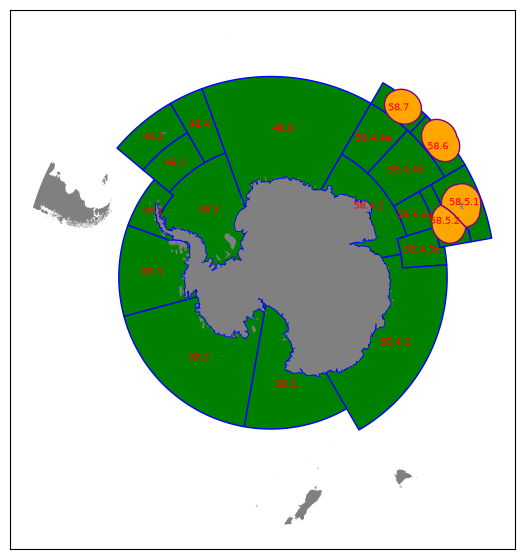

In [1]:
import matplotlib.pyplot as plt

import ccamlrgis as cg
import ccamlrgis.plot as cgplot

asds = cg.load_asds()
eezs = cg.load_eezs()
coastline = cg.load_coastline()
coastline = coastline[coastline["surface"] == "Land"]

fig, ax = plt.subplots(figsize=(7, 7))
cgplot.basemap(ax=ax)
asds.plot(ax=ax, color="green", edgecolor="blue")
eezs.plot(ax=ax, color="orange", edgecolor="purple")
coastline.plot(ax=ax, color="grey")
cgplot.add_labels(ax=ax, mode="auto", layer="ASDs", fontsize=7.5, colour="red")
plt.show()

## 3.2. Offline use

The R tutorial's offline workflow is: load each layer once while online,
`save()` them to a local `.RData` file, then `load()` that file on
subsequent, possibly offline, runs.

`ccamlrgis`'s `load_*` functions do this automatically -- every call is
cached to disk (`ccamlrgis.cache`, ETag-conditional so it only
re-downloads when the source has actually changed), so there is no
separate save/load step. `cache.prefetch()` downloads everything up front
(e.g. before going offline); `cache.info()` reports what's already cached.

In [2]:
from ccamlrgis import cache

print(cache.info())

{'Coast.gpkg': {'bytes': 2453504, 'etag': '"0x8DEEE4FC099C626"', 'last_modified': 'Thu, 30 Jul 2026 15:32:23 GMT', 'sha256': '3ce35a6c382e48f4f11660b639d0e6a8d5701d9604ed08fcf6c327b333c31279', 'url': 'https://github.com/Zephyr-Sylvester/ccamlrgis-py/releases/download/data-v1/Coast.gpkg'}, 'GEBCO2024_5000.tif': {'bytes': 16561930, 'etag': None, 'last_modified': 'Tue, 8 Oct 2024 05:08:50 GMT', 'sha256': 'c49053c11969aa2e610890992d6dedd24cdedd0b768681df50d7d60462e64f37', 'url': 'https://gis.ccamlr.org/geoserver/www/GEBCO2024_5000.tif'}, 'GridData.csv': {'bytes': 7765, 'etag': '"0x8DEEE4FC1181FD4"', 'last_modified': 'Thu, 30 Jul 2026 15:32:24 GMT', 'sha256': 'ee000f6f521d8fac4331f4a454f93c01d90f24e538c5af68d876ccc9a2b21925', 'url': 'https://github.com/Zephyr-Sylvester/ccamlrgis-py/releases/download/data-v1/GridData.csv'}, 'Labels.csv': {'bytes': 4950, 'etag': '"0x8DEEE4FC1915B4A"', 'last_modified': 'Thu, 30 Jul 2026 15:32:25 GMT', 'sha256': '2029cabe358b74585f131f289388d9ea439bfb383d51c3f6